# Notebook 2 — Data Cleaning & Preprocessing

Steps:
1. Scale `Time` and `Amount` features
2. Handle class imbalance (SMOTE oversampling)
3. Train/test split
4. Save processed data for modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

%matplotlib inline

## 1. Load Data

In [ ]:
# Load the raw credit card transaction data
# This is the same file we explored in Notebook 1 (EDA)
df = pd.read_csv('../data/creditcard.csv')

# Check the size of our dataset
# .shape returns (number of rows, number of columns)
# We expect about 284,807 rows (transactions) and 31 columns (features)
print(f'Shape: {df.shape}')

# Check for missing values (empty cells)
# .isnull() finds empty cells, .sum() counts them
# We do .sum().sum() to get the total across all columns
# This should be 0 - this dataset has no missing values
print(f'Missing values: {df.isnull().sum().sum()}')

Shape: (284807, 31)
Missing values: 0


## 2. Scale Time and Amount

In [ ]:
# Create a StandardScaler object
# This will learn the mean and standard deviation, then transform the data
scaler = StandardScaler()

# Scale the Time column
# fit_transform does two things:
#   1. fit: learns the mean and std of Time column
#   2. transform: converts each value to (value - mean) / std
# The double brackets [['Time']] are needed to keep it as a DataFrame column
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Scale the Amount column the same way
# We create a NEW scaler because Amount has different mean/std than Time
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])

# Remove the original Time and Amount columns
# We only want to keep the scaled versions to avoid duplicate information
# (having both original and scaled would confuse the model)
df = df.drop(columns=['Time', 'Amount'])

# Print the new shape to confirm we still have all our data
# We should have 31 columns: 28 V-features + Class + 2 scaled features
print('Scaled Time and Amount. New shape:', df.shape)

Scaled Time and Amount. New shape: (284807, 31)


## 3. Train/Test Split

In [ ]:
# Separate features (X) from the target variable (y)
# X = all columns EXCEPT Class (these are the inputs the model uses)
# y = just the Class column (this is what we want to predict: 0 or 1)
X = df.drop(columns=['Class'])
y = df['Class']

# Split the data into training and testing sets
# Parameters:
#   test_size=0.2: Use 20% of data for testing, 80% for training
#   random_state=42: Use the same "random" split every time (makes results reproducible)
#   stratify=y: Keep the same fraud/legitimate ratio in both train and test
#               Without this, we might get unlucky and have very few frauds in test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print information about the split
# {:,} adds commas to large numbers for easier reading (e.g., 227,845)
print(f'Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}')

# Calculate the fraud rate (percentage of frauds) in each set
# .mean() on binary (0/1) data gives the proportion of 1s
# :.4% formats as percentage with 4 decimal places
print(f'Train fraud rate: {y_train.mean():.4%}')
print(f'Test fraud rate:  {y_test.mean():.4%}')

Train size: 227,845 | Test size: 56,962
Train fraud rate: 0.1729%
Test fraud rate:  0.1720%


## 4. Handle Class Imbalance with SMOTE

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


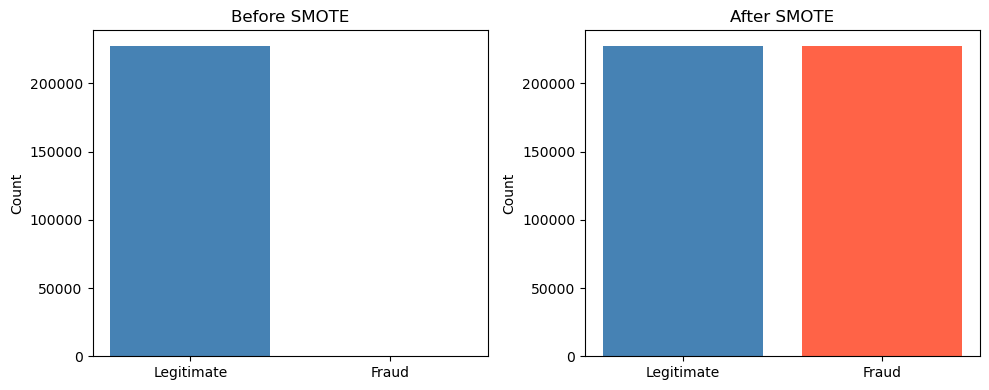

In [ ]:
print('Before SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_res).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), 'Before SMOTE'),
    (pd.Series(y_train_res).value_counts(), 'After SMOTE')
]):
    ax.bar(['Legitimate', 'Fraud'], counts, color=['steelblue', 'tomato'])
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/smote_comparison.png', dpi=150)
plt.show()

## 5. Save Processed Splits

In [ ]:
# First, import the os module to work with folders
import os

# Create the 'processed' folder if it doesn't exist
# exist_ok=True means "don't error if the folder is already there"
os.makedirs('../data/processed', exist_ok=True)

# --- Save the TRAINING set (with SMOTE-resampled data) ---

# Convert the resampled features (X_train_res) back to a DataFrame
# We need to specify column names because fit_resample returns a numpy array
X_train_res_df = pd.DataFrame(X_train_res, columns=X.columns)

# Add the Class column (our target variable)
X_train_res_df['Class'] = y_train_res

# Save to CSV file
# index=False means don't save row numbers as a column
X_train_res_df.to_csv('../data/processed/train_resampled.csv', index=False)

# --- Save the TEST set (original split, NO SMOTE) ---

# Make a copy of the test features
X_test_df = X_test.copy()

# Add the Class column
# .values converts from pandas Series to numpy array (avoids index alignment issues)
X_test_df['Class'] = y_test.values

# Save to CSV file
X_test_df.to_csv('../data/processed/test.csv', index=False)

# Print confirmation messages
print('Saved: data/processed/train_resampled.csv')
print('Saved: data/processed/test.csv')

# WHAT WE SAVED:
# 1. train_resampled.csv: ~454,902 rows (balanced 50/50 fraud/legitimate)
#    - This is what we'll use to train our models in Notebook 3
# 2. test.csv: ~56,962 rows (original 0.17% fraud rate)
#    - This is what we'll use to evaluate our models (honest test)

Saved: data/processed/train_resampled.csv
Saved: data/processed/test.csv


## Summary

- `Time` and `Amount` scaled using `StandardScaler`
- Stratified 80/20 train/test split preserves original fraud ratio
- SMOTE applied to training set only (never to test set — avoids data leakage)
- Processed splits saved for modeling

**Next step:** Notebook 03 — Modeling